# L'IA et la productivité économique : mythe ou réalité mesurable ?

**Auteur :** Manau Salaun
**Date :** Juin 2026

## Question de recherche

Existe-t-il une relation statistiquement significative entre l'adoption de l'intelligence artificielle par les entreprises et la productivité du travail à travers les pays européens ?

C'est une question au cœur des débats économiques actuels. Les institutions internationales (OCDE, FMI) publient des estimations très variées de l'impact de l'IA sur la productivité, sans consensus clair, notamment parce qu'il est difficile de mesurer cet effet à l'échelle macroéconomique. Ce projet propose une analyse empirique simple, transparente et reproductible de cette relation à partir de données officielles.

## Plan de l'analyse

1. Présentation des données et de leurs limites
2. Analyse exploratoire (EDA)
3. Test d'hypothèse : les pays à forte adoption d'IA ont-ils une productivité significativement différente ?
4. Régression simple : quelle est la force du lien entre adoption de l'IA et productivité ?
5. Régression multiple : ce lien tient-il une fois qu'on contrôle pour la richesse du pays ?
6. Vérification des hypothèses du modèle
7. Conclusion et limites


## 1. Données et sources

Toutes les données utilisées proviennent de sources officielles :

| Variable | Source | Année |
|---|---|---|
| Adoption de l'IA par les entreprises | Eurostat (isoc_eb_ai) | 2024 et 2025 |
| Productivité du travail (PIB par heure travaillée) | OCDE / ILO (estimations modélisées) | 2025 |
| PIB réel par habitant | Eurostat (sdg_08_10) | 2023 |

**Limites importantes à garder en tête :**

- Les trois variables ne proviennent pas exactement de la même année (léger décalage temporel).
- L'échantillon est européen (UE + quelques pays associés) : les résultats ne sont pas généralisables au monde entier.
- Une corrélation entre adoption de l'IA et productivité ne prouve pas que l'IA *cause* la productivité — la causalité pourrait aller dans l'autre sens (les pays riches ont plus de moyens à investir dans l'IA), ou être due à un troisième facteur commun.

C'est précisément pour cette dernière raison qu'on inclut le PIB par habitant comme variable de contrôle plus loin dans l'analyse.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv('../data/dataset_final_fr.csv')
df.head()

,pays,adoption_ia_2024,adoption_ia_2025,croissance_adoption_pp,adoption_petites_entreprises,adoption_moyennes_entreprises,adoption_grandes_entreprises,productivite_horaire,pib_par_habitant
0,Denmark,27.58,42.03,14.45,37.5,58.3,74.5,92.2,52510
1,Finland,24.37,37.82,13.45,33.5,51.4,79.4,80.5,36760
2,Sweden,25.09,35.04,9.95,30.7,49.6,71.9,83.9,44620
3,Belgium,24.71,34.54,9.83,28.8,54.5,76.4,91.5,37340
4,Luxembourg,23.73,33.61,9.88,30.5,43.7,58.0,159.5,83320


In [2]:
print(f"Nombre de pays dans l'échantillon : {df.shape[0]}")
print(f"Nombre de variables : {df.shape[1]}")
df.info()

Nombre de pays dans l'échantillon : 31
Nombre de variables : 9
<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   pays                           31 non-null     str    
 1   adoption_ia_2024               31 non-null     float64
 2   adoption_ia_2025               31 non-null     float64
 3   croissance_adoption_pp         31 non-null     float64
 4   adoption_petites_entreprises   30 non-null     float64
 5   adoption_moyennes_entreprises  31 non-null     float64
 6   adoption_grandes_entreprises   30 non-null     float64
 7   productivite_horaire           31 non-null     float64
 8   pib_par_habitant               31 non-null     int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 2.3 KB


## 2. Analyse exploratoire (EDA)

Avant tout test ou modèle, il faut comprendre la forme de nos données : leur distribution, leurs valeurs manquantes, et surtout la relation visuelle entre nos variables d'intérêt.


In [3]:
df.isnull().sum()

pays                             0
adoption_ia_2024                 0
adoption_ia_2025                 0
croissance_adoption_pp           0
adoption_petites_entreprises     1
adoption_moyennes_entreprises    0
adoption_grandes_entreprises     1
productivite_horaire             0
pib_par_habitant                 0
dtype: int64

On note une valeur manquante pour le Monténégro sur l'adoption des petites et grandes entreprises : Eurostat indique cette donnée comme confidentielle dans le rapport source. Comme ces deux colonnes ne sont pas utilisées dans la régression principale (on utilise `adoption_ia_2025`, l'indicateur global), on garde cette ligne sans la supprimer.

In [4]:
df.describe().round(2)

,adoption_ia_2024,adoption_ia_2025,croissance_adoption_pp,adoption_petites_entreprises,adoption_moyennes_entreprises,adoption_grandes_entreprises,productivite_horaire,pib_par_habitant
count,31.00,31.00,31.00,30.00,31.00,30.00,31.00,31.00
mean,13.73,19.88,6.15,17.34,28.95,51.82,68.62,28708.71
std,7.22,10.30,4.04,9.29,14.57,16.63,33.18,19739.38
min,3.07,5.21,-0.88,4.10,7.80,18.30,29.80,6500.00
25%,8.06,10.24,2.93,9.40,15.30,40.92,48.10,14950.00
50%,11.26,18.16,6.22,16.20,28.80,53.00,56.50,22130.00
75%,20.52,27.43,9.59,24.68,39.65,64.00,82.20,37050.00
max,27.58,42.03,14.45,37.50,58.30,79.40,164.70,83320.00


### 2.1. Distribution des deux variables principales

On regarde d'abord si nos deux variables principales (adoption de l'IA et productivité) suivent une distribution à peu près normale, ou si elles sont fortement asymétriques — ce qui influencera l'interprétation des analyses suivantes.

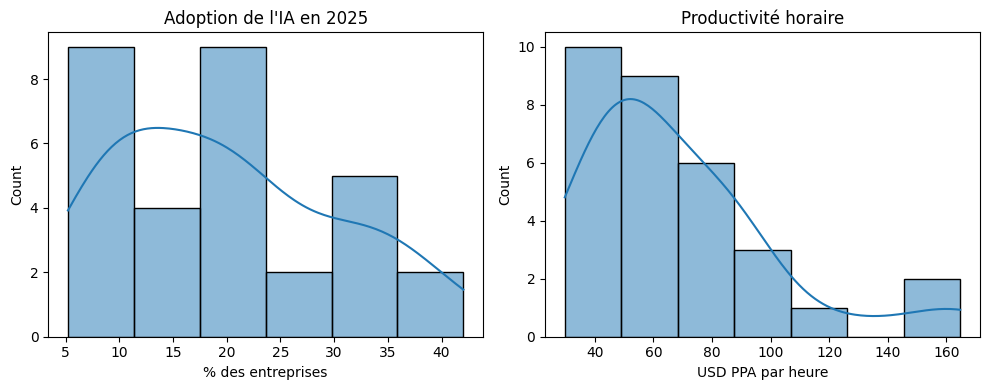

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df['adoption_ia_2025'], ax=axes[0], kde=True)
axes[0].set_title("Adoption de l'IA en 2025")
axes[0].set_xlabel("% des entreprises")

sns.histplot(df['productivite_horaire'], ax=axes[1], kde=True)
axes[1].set_title("Productivité horaire")
axes[1].set_xlabel("USD PPA par heure")

plt.tight_layout()
plt.show()

Les deux distributions sont asymétriques à droite : la majorité des pays ont une adoption de l'IA et une productivité modérées, avec une minorité de pays (Danemark, Finlande, Irlande, Luxembourg) nettement au-dessus du reste. C'est cohérent avec ce qu'on sait de l'économie européenne — un petit groupe de pays nordiques et de "hubs" économiques (souvent liés à la présence de multinationales) tire les moyennes vers le haut.

### 2.2. La relation centrale : adoption de l'IA et productivité

C'est le graphique le plus important de cette section : il visualise directement notre question de recherche.

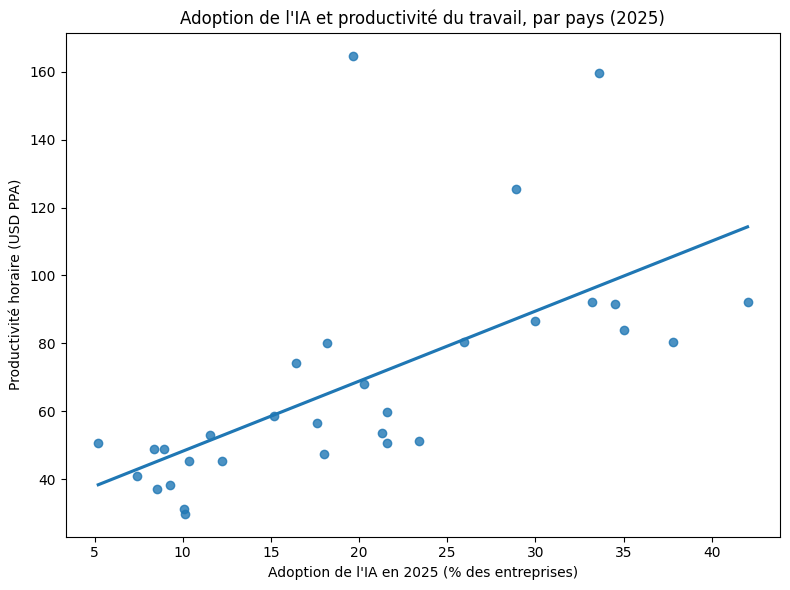

Coefficient de corrélation : r = 0.640


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(x='adoption_ia_2025', y='productivite_horaire', data=df, ax=ax, ci=None)
ax.set_xlabel("Adoption de l'IA en 2025 (% des entreprises)")
ax.set_ylabel("Productivité horaire (USD PPA)")
ax.set_title("Adoption de l'IA et productivité du travail, par pays (2025)")
plt.tight_layout()
plt.show()

correlation = df['adoption_ia_2025'].corr(df['productivite_horaire'])
print(f"Coefficient de corrélation : r = {correlation:.3f}")

On observe une corrélation positive modérée (r ≈ 0.64) entre l'adoption de l'IA et la productivité horaire. Les pays comme le Danemark, la Finlande et la Suède combinent une forte adoption de l'IA et une bonne productivité, tandis que la Roumanie, la Bulgarie et la Pologne se trouvent à l'autre extrémité sur les deux variables.

Mais deux pays sortent nettement du nuage de points : l'Irlande et le Luxembourg affichent une productivité très élevée (plus de 150 USD/heure) sans avoir l'adoption de l'IA la plus forte. Ce n'est pas une anomalie statistique — c'est un fait économique bien documenté : la productivité de ces deux pays est gonflée par la présence de sièges de multinationales qui y déclarent leur propriété intellectuelle, sans que cela reflète une productivité "réelle" de leur main-d'œuvre locale.

Cette observation est importante : elle suggère qu'une partie de la relation observée pourrait être due à des facteurs structurels (richesse, présence de multinationales) plutôt qu'à un effet direct de l'IA. C'est exactement ce qu'on va vérifier avec la régression multiple.

### 2.3. Le risque de variable omise : le rôle du PIB par habitant

Avant de conclure quoi que ce soit, on vérifie si une troisième variable — la richesse du pays — pourrait expliquer à la fois l'adoption de l'IA et la productivité.

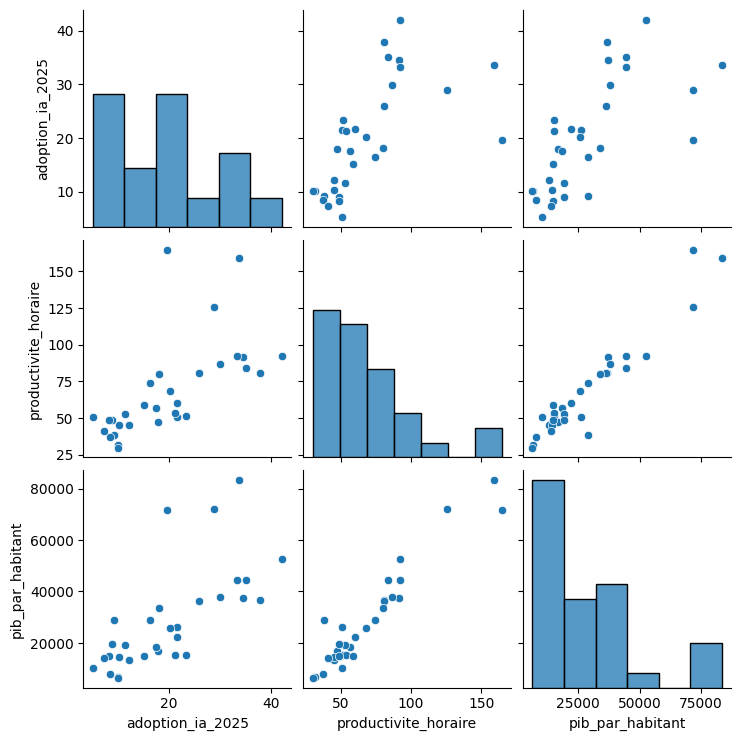

In [7]:
vars_interet = ['adoption_ia_2025', 'productivite_horaire', 'pib_par_habitant']
sns.pairplot(df[vars_interet])
plt.show()

In [8]:
correlations = df[vars_interet].corr().round(3)
correlations

,adoption_ia_2025,productivite_horaire,pib_par_habitant
adoption_ia_2025,1.000,0.640,0.696
productivite_horaire,0.640,1.000,0.954
pib_par_habitant,0.696,0.954,1.000


Le constat est clair et c'est le point le plus important de l'EDA : le PIB par habitant est **fortement corrélé** à la fois avec la productivité (r ≈ 0.95) et avec l'adoption de l'IA (r ≈ 0.70). 

En d'autres termes, les pays riches ont à la fois une meilleure productivité ET une plus forte adoption de l'IA — mais on ne sait pas encore si l'IA contribue réellement à la productivité, ou si les deux sont simplement des symptômes de la richesse du pays. C'est le problème classique du **biais de variable omise** en économétrie, et c'est précisément ce qu'une régression multiple avec variable de contrôle permet de démêler.

## 3. Test d'hypothèse : les pays à forte adoption d'IA ont-ils une productivité différente ?

Avant de passer à la régression, on pose une question plus simple et plus directe avec un test t : si on divise les pays en deux groupes selon leur niveau d'adoption de l'IA (au-dessus ou en dessous de la médiane), leur productivité moyenne diffère-t-elle de façon statistiquement significative ?

**H0 :** la productivité moyenne est la même dans le groupe à forte adoption et dans le groupe à faible adoption.
**Ha :** la productivité moyenne diffère entre les deux groupes.


In [9]:
mediane_adoption = df['adoption_ia_2025'].median()

groupe_forte = df[df['adoption_ia_2025'] >= mediane_adoption]['productivite_horaire']
groupe_faible = df[df['adoption_ia_2025'] < mediane_adoption]['productivite_horaire']

print(f"Médiane d'adoption de l'IA : {mediane_adoption:.2f} %")
print(f"Groupe forte adoption (n={len(groupe_forte)}) : productivité moyenne = {groupe_forte.mean():.2f}")
print(f"Groupe faible adoption (n={len(groupe_faible)}) : productivité moyenne = {groupe_faible.mean():.2f}")

Médiane d'adoption de l'IA : 18.16 %
Groupe forte adoption (n=16) : productivité moyenne = 88.83
Groupe faible adoption (n=15) : productivité moyenne = 47.06


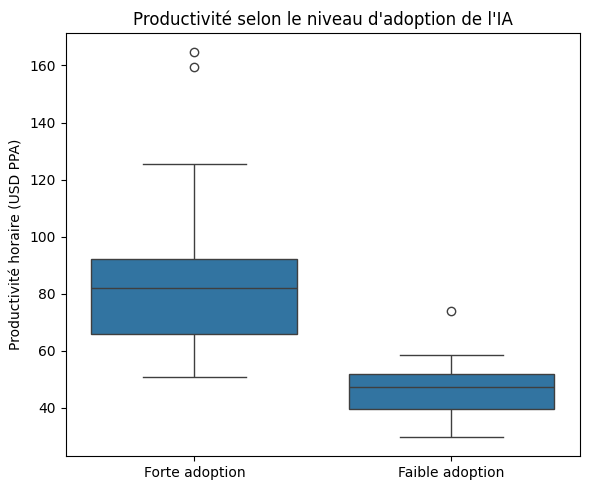

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
df['groupe_adoption'] = np.where(df['adoption_ia_2025'] >= mediane_adoption, 'Forte adoption', 'Faible adoption')
sns.boxplot(x='groupe_adoption', y='productivite_horaire', data=df, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Productivité horaire (USD PPA)")
ax.set_title("Productivité selon le niveau d'adoption de l'IA")
plt.tight_layout()
plt.show()

In [11]:
# Test t de Welch : on ne suppose pas que les variances des deux groupes sont égales,
# une précaution raisonnable avec un échantillon aussi petit (31 pays)
t_stat, p_value = stats.ttest_ind(groupe_forte, groupe_faible, equal_var=False)
print(f"Statistique t = {t_stat:.3f}")
print(f"P-value = {p_value:.4f}")

Statistique t = 4.601
P-value = 0.0002


La p-value (0.0002) est largement inférieure au seuil de 0.05 : on rejette H0. Les pays à forte adoption de l'IA ont une productivité significativement plus élevée que les pays à faible adoption — une différence de plus de 40 USD par heure entre les deux groupes.

**Attention à l'interprétation** : ce test confirme qu'il existe une différence statistiquement significative, mais il ne dit rien sur la *cause* de cette différence. Comme on l'a vu dans l'EDA, ces mêmes pays à forte adoption de l'IA sont aussi les pays les plus riches. La régression multiple qui suit va permettre de vérifier si l'IA garde un effet propre une fois qu'on contrôle pour cette richesse.

## 4. Régression simple : quantifier la relation

Le test précédent confirme une différence entre groupes, mais une régression linéaire permet d'aller plus loin : quantifier *combien* la productivité augmente pour chaque point d'adoption de l'IA supplémentaire, et mesurer la part de la variation totale que cette seule variable explique.


In [12]:
model_simple = ols('productivite_horaire ~ adoption_ia_2025', data=df).fit()
print(model_simple.summary())

                             OLS Regression Results                             
Dep. Variable:     productivite_horaire   R-squared:                       0.410
Model:                              OLS   Adj. R-squared:                  0.390
Method:                   Least Squares   F-statistic:                     20.17
Date:                  Wed, 17 Jun 2026   Prob (F-statistic):           0.000104
Time:                          11:54:28   Log-Likelihood:                -143.85
No. Observations:                    31   AIC:                             291.7
Df Residuals:                        29   BIC:                             294.6
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           

**Interprétation :**

- **R² = 0.410** : l'adoption de l'IA explique 41 % de la variation de la productivité entre pays. C'est un résultat notable pour une seule variable en sciences sociales.
- **Coefficient = 2.06** : chaque point de pourcentage supplémentaire d'adoption de l'IA est associé à une hausse de 2.06 USD de productivité horaire, en moyenne.
- **P-value < 0.001** : ce coefficient est statistiquement très significatif.

Pris isolément, ce résultat semble confirmer l'hypothèse d'un lien fort entre IA et productivité. Mais on sait déjà, grâce à l'EDA, qu'une variable cachée — le PIB par habitant — pourrait expliquer une grande partie de cette relation. C'est ce qu'on teste maintenant.

## 5. Régression multiple : l'effet de l'IA résiste-t-il au contrôle de la richesse ?

On ajoute le PIB par habitant comme variable de contrôle. L'objectif : isoler l'effet propre de l'adoption de l'IA sur la productivité, *toutes choses égales par ailleurs* — c'est-à-dire en neutralisant l'effet de la richesse globale du pays.


In [13]:
model_multiple = ols('productivite_horaire ~ adoption_ia_2025 + pib_par_habitant', data=df).fit()
print(model_multiple.summary())

                             OLS Regression Results                             
Dep. Variable:     productivite_horaire   R-squared:                       0.911
Model:                              OLS   Adj. R-squared:                  0.905
Method:                   Least Squares   F-statistic:                     144.2
Date:                  Wed, 17 Jun 2026   Prob (F-statistic):           1.81e-15
Time:                          11:54:28   Log-Likelihood:                -114.46
No. Observations:                    31   AIC:                             234.9
Df Residuals:                        28   BIC:                             239.2
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           

**C'est le résultat central de ce projet, et il est sans ambiguïté :**

- **R² = 0.911** : les deux variables ensemble expliquent 91 % de la variation de la productivité — une nette amélioration par rapport à la régression simple (41 %).
- **Coefficient de `pib_par_habitant` = 0.0017, p < 0.001** : très significatif. Le PIB par habitant est un puissant prédicteur de la productivité (ce qui est logique : les deux mesurent des aspects proches de la richesse économique).
- **Coefficient de `adoption_ia_2025` = -0.145, p = 0.569** : **non significatif**. Une fois qu'on contrôle pour le PIB par habitant, l'adoption de l'IA n'a plus d'effet statistiquement distinct sur la productivité — le coefficient devient même légèrement négatif, ce qui est davantage le signe d'un bruit statistique que d'un véritable effet.

**Ce que ça signifie économiquement :** la relation observée dans la régression simple entre IA et productivité ne reflète pas un effet propre de l'IA, mais largement le fait que les pays plus riches adoptent à la fois plus l'IA et sont plus productifs pour d'autres raisons (infrastructures, éducation, institutions, présence de multinationales). C'est un exemple concret de **biais de variable omise** : ignorer le PIB par habitant dans la régression simple surestimait l'effet apparent de l'IA.

## 6. Vérification des hypothèses du modèle

Avant de faire confiance à ces résultats, on vérifie que le modèle de régression multiple respecte ses hypothèses de base. Avec seulement 31 observations, ces vérifications sont d'autant plus importantes.


### 6.1. Normalité des résidus

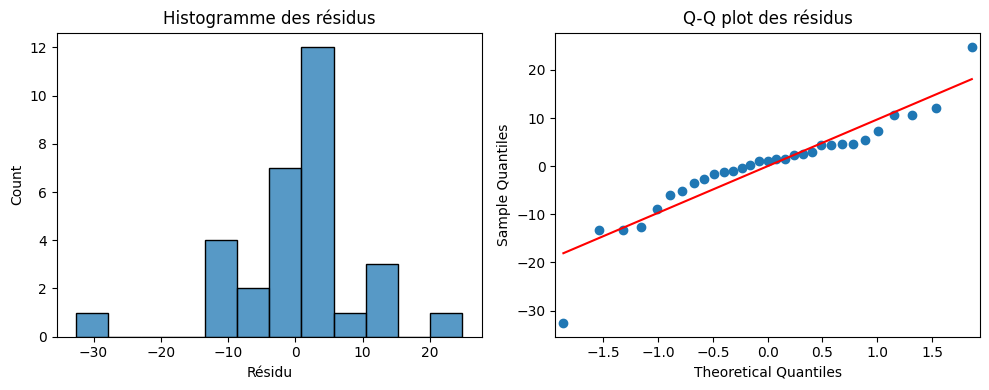

In [14]:
residuals = model_multiple.resid

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(residuals, ax=axes[0])
axes[0].set_title("Histogramme des résidus")
axes[0].set_xlabel("Résidu")

sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("Q-Q plot des résidus")

plt.tight_layout()
plt.show()

L'histogramme est globalement centré sur 0 mais avec une légère asymétrie, et le Q-Q plot montre un écart notable à l'extrémité gauche (un pays dont le résidu est nettement plus négatif que prévu — probablement un petit pays d'Europe de l'Est où le modèle surestime la productivité). Avec un échantillon de seulement 31 pays, ce genre d'écart ponctuel a un poids relativement important. La normalité est raisonnable sans être parfaite.

### 6.2. Homoscédasticité (variance constante des résidus)

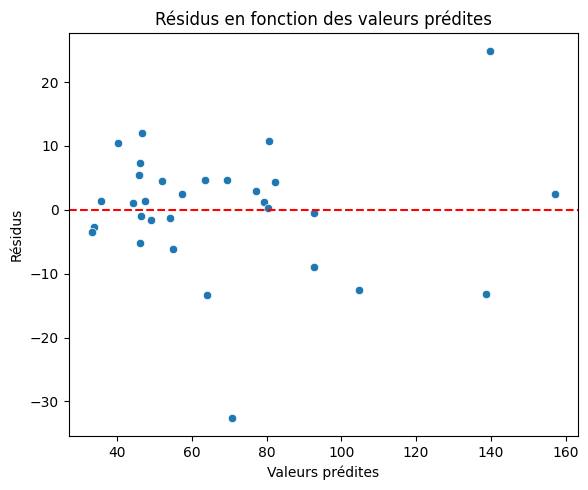

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(x=model_multiple.fittedvalues, y=model_multiple.resid, ax=ax)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Valeurs prédites")
ax.set_ylabel("Résidus")
ax.set_title("Résidus en fonction des valeurs prédites")
plt.tight_layout()
plt.show()

La dispersion des résidus est raisonnablement stable le long de l'axe des valeurs prédites, sans forme d'entonnoir marquée. L'hypothèse d'homoscédasticité semble globalement respectée, avec le même point atypique déjà repéré dans le Q-Q plot.

### 6.3. Multicolinéarité (VIF)

C'est l'hypothèse la plus importante à vérifier ici, puisqu'on sait déjà depuis l'EDA que l'adoption de l'IA et le PIB par habitant sont corrélés entre eux (r ≈ 0.70).

In [16]:
X = df[['adoption_ia_2025', 'pib_par_habitant']]
vif_values = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
df_vif = pd.DataFrame({'variable': X.columns, 'VIF': vif_values})
df_vif

,variable,VIF
0,adoption_ia_2025,6.140785
1,pib_par_habitant,6.140785


Un VIF de 6.1 pour les deux variables indique une multicolinéarité notable (au-dessus du seuil de prudence de 5, mais sous le seuil critique de 10). Ce n'est pas une surprise : c'est la conséquence directe et attendue du fait que les pays riches adoptent davantage l'IA.

**Cette multicolinéarité ne remet pas en cause la conclusion principale** — au contraire, elle l'explique. Le coefficient de l'adoption de l'IA n'est pas significatif précisément *parce que* cette variable porte une information très proche de celle du PIB par habitant une fois les deux incluses ensemble. C'est un signe cohérent avec notre interprétation : l'IA et la richesse du pays racontent en grande partie la même histoire statistique.

## 7. Conclusion de l'analyse principale

**Réponse à la question de recherche :** sur cet échantillon de 31 pays européens, on ne trouve pas de preuve solide d'un effet propre de l'adoption de l'IA sur la productivité du travail, une fois qu'on contrôle pour le niveau de richesse du pays.

### Ce qu'on peut dire

- Il existe bien une corrélation simple, significative, entre adoption de l'IA et productivité (r ≈ 0.64).
- Mais cette corrélation s'effondre statistiquement dès qu'on ajoute le PIB par habitant comme variable de contrôle : le coefficient de l'IA devient non significatif (p = 0.57), alors que le PIB par habitant explique l'essentiel de la variation de productivité (R² passe de 0.41 à 0.91).
- Le diagnostic de multicolinéarité (VIF ≈ 6.1) confirme que l'adoption de l'IA et la richesse du pays véhiculent en grande partie la même information statistique dans cet échantillon.

### Ce qu'on ne peut PAS dire

- On ne peut pas conclure que "l'IA n'a aucun effet sur la productivité" — l'absence de preuve n'est pas une preuve d'absence. Avec seulement 31 observations, le modèle a une puissance statistique limitée pour détecter un effet modeste de l'IA si celui-ci existe réellement.
- On ne peut pas non plus établir de lien de causalité dans un sens ou dans l'autre. Il est tout aussi plausible que les pays riches aient plus de moyens à investir dans l'IA (causalité inverse) que l'inverse.
- L'échantillon européen ne permet pas de généraliser ces résultats à l'économie mondiale.

### Pourquoi ce résultat est utile

Ce projet illustre un point méthodologique central en économie appliquée : une corrélation qui semble confirmer une hypothèse intuitive ("l'IA stimule la productivité") peut en réalité refléter un facteur de confusion plus profond. C'est précisément le type de prudence qu'on attend d'une analyse économique sérieuse — et qui distingue une statistique descriptive d'une véritable inférence économétrique.

### Pistes pour approfondir

- Utiliser des données en panel (plusieurs années pour chaque pays) plutôt qu'une coupe transversale à un instant donné, ce qui permettrait de mieux isoler l'effet de l'IA dans le temps.
- Décomposer l'adoption de l'IA par secteur économique plutôt qu'au niveau agrégé du pays, pour voir si l'effet diffère selon les secteurs (par exemple, dans les services à forte intensité informationnelle vs l'industrie manufacturière).
- Élargir l'échantillon à des pays hors Europe (OCDE, Canada, États-Unis) pour tester la robustesse du résultat dans un contexte différent.


## 8. Ouverture : la dynamique d'adoption plutôt que le niveau

La conclusion précédente repose sur le *niveau* d'adoption de l'IA en 2025. Mais une limite qu'on avait identifiée est qu'il s'agit d'une photographie à un instant donné — elle ne capture aucune dynamique.

On dispose d'une variable supplémentaire dans le dataset : la **croissance de l'adoption de l'IA entre 2024 et 2025**, en points de pourcentage (`croissance_adoption_pp`). C'est une autre façon de poser la question : ce n'est pas "les pays qui utilisent le plus l'IA aujourd'hui sont-ils plus productifs ?", mais plutôt "les pays où l'adoption de l'IA progresse le plus vite sont-ils plus productifs ?". Si l'IA avait un effet causal réel et récent sur la productivité, on pourrait s'attendre à ce que cette dynamique d'adoption soit un signal plus pertinent qu'un simple niveau, qui dépend beaucoup de l'historique économique du pays.


In [17]:
model_croissance = ols('productivite_horaire ~ croissance_adoption_pp', data=df).fit()
print(model_croissance.summary())

                             OLS Regression Results                             
Dep. Variable:     productivite_horaire   R-squared:                       0.238
Model:                              OLS   Adj. R-squared:                  0.212
Method:                   Least Squares   F-statistic:                     9.057
Date:                  Wed, 17 Jun 2026   Prob (F-statistic):            0.00537
Time:                          11:54:29   Log-Likelihood:                -147.83
No. Observations:                    31   AIC:                             299.7
Df Residuals:                        29   BIC:                             302.5
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercep

Pris isolément, ce modèle est moins puissant que celui basé sur le niveau (R² = 0.24 contre 0.41), mais reste statistiquement significatif (p = 0.005). La question décisive reste la même : cet effet résiste-t-il au contrôle du PIB par habitant ?

In [18]:
corr_croissance_pib = df['croissance_adoption_pp'].corr(df['pib_par_habitant'])
print(f"Corrélation croissance adoption IA / PIB par habitant : {corr_croissance_pib:.3f}")

model_multiple_croissance = ols('productivite_horaire ~ croissance_adoption_pp + pib_par_habitant', data=df).fit()
print(model_multiple_croissance.summary())

Corrélation croissance adoption IA / PIB par habitant : 0.501
                             OLS Regression Results                             
Dep. Variable:     productivite_horaire   R-squared:                       0.911
Model:                              OLS   Adj. R-squared:                  0.904
Method:                   Least Squares   F-statistic:                     142.6
Date:                  Wed, 17 Jun 2026   Prob (F-statistic):           2.09e-15
Time:                          11:54:29   Log-Likelihood:                -114.62
No. Observations:                    31   AIC:                             235.2
Df Residuals:                        28   BIC:                             239.5
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [19]:
X = df[['croissance_adoption_pp', 'pib_par_habitant']]
vif_values = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
pd.DataFrame({'variable': X.columns, 'VIF': vif_values})

,variable,VIF
0,croissance_adoption_pp,3.557184
1,pib_par_habitant,3.557184


**Ce résultat renforce la conclusion principale plutôt que de la contredire.**

Même en changeant d'angle — en testant la dynamique de l'adoption plutôt que son niveau — le constat est identique : une fois le PIB par habitant pris en compte, la croissance de l'adoption de l'IA n'a plus d'effet statistiquement significatif sur la productivité (p = 0.839). 

Un détail technique notable : le VIF est ici plus faible (3.6 contre 6.1 dans le modèle de niveau), ce qui signifie que la multicolinéarité entre cette variable et le PIB par habitant est moins extrême. Pourtant, la conclusion reste la même. Cela suggère que la non-significativité de l'IA n'est pas seulement un artefact de colinéarité, mais un résultat plus robuste : que l'on regarde le niveau d'adoption de l'IA ou sa progression récente, on ne trouve pas d'effet propre détectable sur la productivité une fois la richesse du pays prise en compte.

## 9. Ouverture : une typologie de pays par regroupement (K-Means)

Les sections précédentes répondent à une question de nature causale : l'IA a-t-elle un effet sur la productivité ? La réponse, nuancée, est non — pas une fois la richesse contrôlée. Mais on peut poser une question différente, de nature descriptive plutôt que causale : **existe-t-il des profils-pays distincts** qui combinent différemment adoption de l'IA, productivité et richesse ?

C'est une question légitime pour le K-Means, parce qu'on ne lui demande pas d'établir une causalité — seulement de regrouper les pays qui se ressemblent sur ces trois dimensions. On utilise les trois variables déjà centrales dans l'analyse : adoption de l'IA en 2025, productivité horaire et PIB par habitant, toutes standardisées pour que chacune compte également dans le calcul des distances.


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

vars_cluster = ['adoption_ia_2025', 'productivite_horaire', 'pib_par_habitant']
X = df[vars_cluster].copy()
X_scaled = StandardScaler().fit_transform(X)

### 9.1. Choix du nombre de clusters

On teste plusieurs valeurs de k avec la méthode du coude (inertie) et le score de silhouette, pour choisir un nombre de groupes à la fois statistiquement justifié et interprétable — avec seulement 31 pays, on évite de chercher trop de groupes.

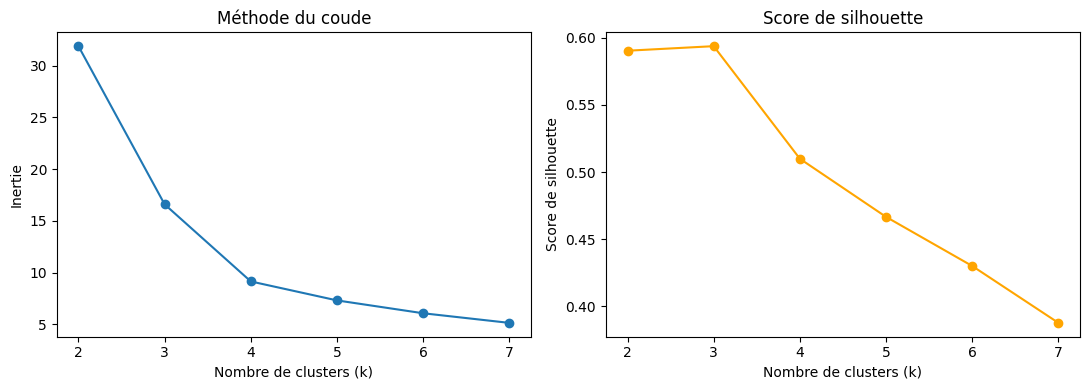

In [21]:
inertias, sil_scores = [], []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du coude')

axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Score de silhouette')
axes[1].set_title('Score de silhouette')
plt.tight_layout()
plt.show()

Le score de silhouette est maximal à **k=3** (0.594), tout en restant proche de k=2. La méthode du coude montre aussi une nette inflexion après k=3. On retient donc 3 groupes — un choix qui reste interprétable pour un échantillon de cette taille.

### 9.2. Les trois profils de pays

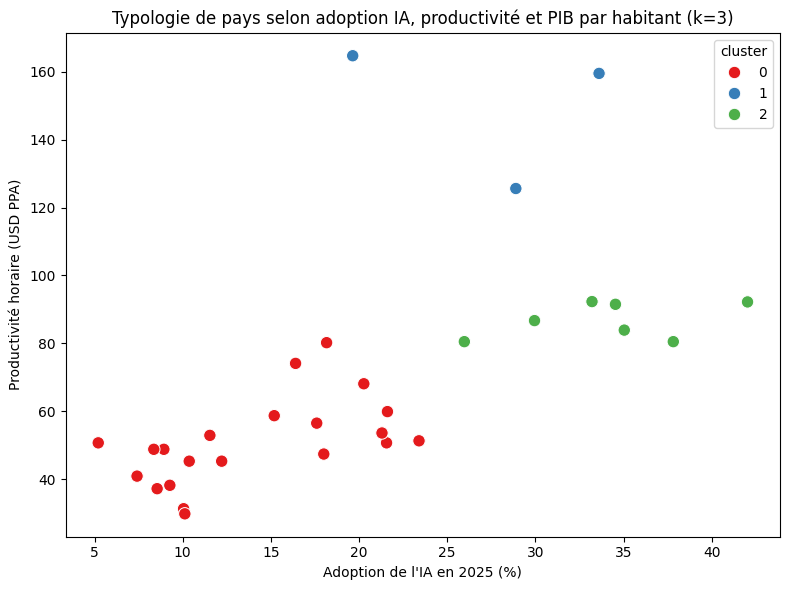

In [22]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='adoption_ia_2025', y='productivite_horaire', hue='cluster',
                 palette='Set1', data=df, s=80, ax=ax)
ax.set_xlabel("Adoption de l'IA en 2025 (%)")
ax.set_ylabel("Productivité horaire (USD PPA)")
ax.set_title("Typologie de pays selon adoption IA, productivité et PIB par habitant (k=3)")
plt.tight_layout()
plt.show()

In [23]:
df.groupby('cluster')[vars_cluster].mean().round(1)

,adoption_ia_2025,productivite_horaire,pib_par_habitant
cluster,,,
0,14.1,50.9,17773.3
1,27.4,149.9,75630.0
2,34.1,86.8,41405.7


In [24]:
for c in sorted(df['cluster'].unique()):
    pays_cluster = df[df['cluster'] == c]['pays'].tolist()
    print(f"Cluster {c} (n={len(pays_cluster)}) : {', '.join(pays_cluster)}")
    print()

Cluster 0 (n=21) : Estonia, Slovenia, Malta, Lithuania, Spain, France, Slovakia, Czechia, Italy, Croatia, Latvia, Portugal, Hungary, Cyprus, Greece, Bulgaria, Poland, Romania, Montenegro, Serbia, Turkiye

Cluster 1 (n=3) : Luxembourg, Ireland, Norway

Cluster 2 (n=7) : Denmark, Finland, Sweden, Belgium, Netherlands, Austria, Germany



**Trois profils économiques se dégagent clairement :**

- **Cluster 0 — Europe centrale, orientale et méditerranéenne (n=21)** : adoption de l'IA modérée (14 % en moyenne), productivité et PIB par habitant plus faibles. C'est le groupe le plus large, qui regroupe la majorité des pays de l'échantillon — de la Pologne au Portugal en passant par la Grèce et la Roumanie.

- **Cluster 1 — Hubs à multinationales (n=3)** : Luxembourg, Irlande et Norvège. Ce sont précisément les trois pays identifiés comme outliers dans l'EDA dès le départ. Leur productivité est exceptionnellement élevée (150 en moyenne) sans que leur adoption de l'IA soit la plus forte — un signal cohérent avec l'explication structurelle déjà avancée (présence de multinationales, secteur pétrolier pour la Norvège, effets comptables liés à la propriété intellectuelle).

- **Cluster 2 — Europe du Nord et économies digitales avancées (n=7)** : Danemark, Finlande, Suède, Belgique, Pays-Bas, Autriche, Allemagne. C'est le groupe avec la plus forte adoption de l'IA (34 % en moyenne) et une bonne productivité, sans atteindre les niveaux extrêmes du cluster des hubs à multinationales.

**Le lien avec la conclusion principale du projet :** ce regroupement confirme, par une méthode complètement différente, l'observation centrale de l'analyse. Le cluster avec la *plus forte* adoption de l'IA (cluster 2, 34 %) n'est pas celui avec la *plus forte* productivité — c'est le cluster 1 (hubs à multinationales, adoption IA moyenne de seulement 27 %) qui domine sur ce plan, porté par des facteurs structurels qui n'ont rien à voir avec l'IA. Le K-Means, sans aucune hypothèse causale, dessine la même histoire que la régression : la richesse et la structure économique d'un pays comptent davantage que son niveau d'adoption de l'IA pour expliquer sa productivité.

## 10. Conclusion générale

Ce projet répond à une question simple — l'adoption de l'IA est-elle liée à la productivité économique ? — en suivant une démarche progressive, où chaque étape remet en question la précédente.

**Ce que l'ensemble de l'analyse montre :**

1. Une corrélation simple existe bien entre adoption de l'IA et productivité (r = 0.64), et un test t confirme une différence significative de productivité entre pays à forte et à faible adoption.
2. Mais cette relation s'effondre statistiquement dès qu'on contrôle pour le PIB par habitant : le coefficient de l'IA devient non significatif, alors que la richesse du pays explique l'essentiel de la variation (R² = 0.91).
3. Ce résultat n'est pas un artefact lié à la façon de mesurer l'adoption de l'IA : que l'on utilise le *niveau* d'adoption en 2025 ou sa *croissance* récente (2024-2025), la conclusion reste identique une fois la richesse prise en compte — avec même une multicolinéarité plus faible pour la croissance, ce qui renforce la robustesse du constat.
4. Une approche complètement différente, le clustering K-Means, fait émerger trois profils de pays sans aucune hypothèse causale — et ces profils racontent la même histoire : le groupe le plus productif (les hubs à multinationales comme l'Irlande et le Luxembourg) n'est pas celui qui adopte le plus l'IA.

**La conclusion d'ensemble** est donc qu'à ce stade, avec les données disponibles, on ne trouve pas de preuve solide d'un effet propre de l'IA sur la productivité macroéconomique en Europe — l'essentiel de ce qu'on observe en corrélation simple reflète la richesse structurelle des pays plutôt qu'un effet spécifique de la technologie. C'est un résultat qui mérite d'être pris au sérieux à l'heure où l'IA est souvent présentée comme un facteur de transformation économique immédiat et automatique : les données disponibles aujourd'hui, à l'échelle macro et sur un échantillon limité, ne permettent pas de confirmer cette intuition aussi simplement qu'on pourrait le penser.

Cela ne signifie pas que l'IA n'a pas d'effet — seulement que cet effet, s'il existe, est plus subtil qu'une simple comparaison entre pays ne peut le révéler, et qu'il faudra des données plus fines (en panel, par secteur, ou au niveau de l'entreprise plutôt que du pays) pour le détecter avec plus de certitude.
